# Linear Regression

Linear Regression model prediction : <br>
<b>y = A0 + A1x1 + A2x2 + ... Anxn</b> <br>
In this equation: <br>
 - y is the predicted value.
 - n is the number of features.
 - xi is the ith feature value
 - Aj is the jth model parameter, including the bias term A0 and the feature weights A1, A2, ... An. <br>

This can be written much more concisely using a vectorized form, as shown below : <br>
<b>y = h(x) = A . x</b>

The MSE of a linear regression hypothesis h on a training set X is calculated using below equation : <br>
<b>MSE(X, y, h) = 1/m <sub>i=1</sub>∑<sup>m</sup> (A'x<sup>(i)</sup> - y<sup>(i)</sup>)<sup>2</sup></b><br><br> 

## The Normal Equation

<b>A = (X'X)<sup>-1</sup> X' y</b>

In [5]:
# Let's generate some linear-looking data to test this equation on : 
import numpy as np 

rng = np.random.default_rng(seed=42)
m = 200 # number of instances
X = 2 * rng.random((m, 1)) # column vector 
y = 4 + 3 * X + rng.standard_normal((m, 1)) # # column vector 

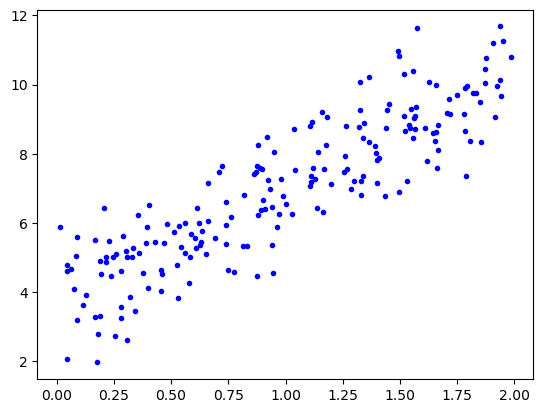

In [6]:
import matplotlib.pyplot as plt 

plt.plot(X, y, "b.", label = "Line graph", linewidth=2)
plt.show()

In [7]:
# Now let's compute A using the normal equation. 

from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X) # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y 
theta_best

array([[3.69084138],
       [3.32960458]])

In [8]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)  # add x0 = 1 to each instance
y_predict = X_new_b @ theta_best
y_predict

array([[ 3.69084138],
       [10.35005055]])

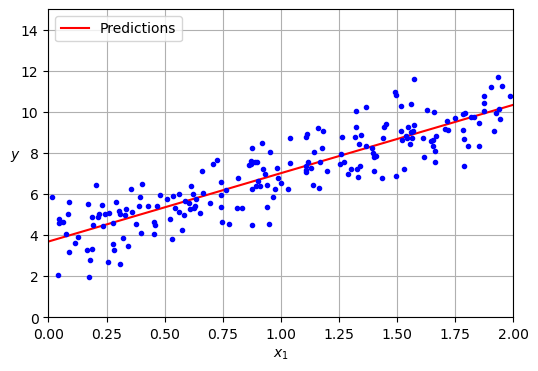

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting
plt.plot(X_new, y_predict, "r-", label="Predictions")
plt.plot(X, y, "b.")

# extra code – beautifies Figure 4–2
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc="upper left")

plt.show()

In [10]:
# Performing linear regression using Scikit-Learn is relatively straightforward: 

from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X,y)
linreg.intercept_, linreg.coef_

(array([3.69084138]), array([[3.32960458]]))

In [11]:
linreg.predict(X_new)

array([[ 3.69084138],
       [10.35005055]])

The `LinearRegression` class is based on the `scipy.linalg.lstsq()` function (the name stands for "least squares"), which you could call directly:

In [13]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[3.69084138],
       [3.32960458]])

## Gradient Descent 

### Batch Gradient Descent

Gradient Descent step 
 - <b>A<sup>(next step)</sup> = A - eta * Gradient_wrt_A(MSE(A))</b><br>

Where MSE = Mean Squared Error

In [17]:
# Let's look at a quick implementation of this algorithm :
eta = 0.1 # Learning rate 
n_epochs = 1000
m = len(X_b) # Number of instances 

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2,1)) # randomly initialized model parameters 

for epoch in range(n_epochs): 
    gradients = 2 / m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta * gradients 

In [20]:
theta

array([[3.69084138],
       [3.32960458]])

### Stochastic Gradient Descent 

In [33]:
n_epochs = 50
t0, t1 = 5, 50 # Learning schedule hyperparameters. 

def learning_schedule(t):
    return t0 / (t + t1)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2,1)) # randomly initialized model parameters 

for epoch in range(n_epochs): 
    for iteration in range(m):
        random_index = rng.integers(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi) # for SGD, do not divide by m
        eta = learning_schedule(epoch*m + iteration)
        theta = theta - eta * gradients 

In [35]:
theta

array([[3.69826475],
       [3.30748311]])

In [37]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01, n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel()) # y.ravel() because fit() expects 1D targets 

SGDRegressor(n_iter_no_change=100, penalty=None, random_state=42, tol=1e-05)

In [39]:
sgd_reg.intercept_, sgd_reg.coef_

(array([3.68899733]), array([3.33054574]))

# Polynomial Regression

In [44]:
rng = np.random.default_rng(seed=42)
m = 200 # number of instances
X = 6 * rng.random((m,1)) - 3 
y = 0.5 * X ** 2 + X + 2 + rng.standard_normal((m,1))

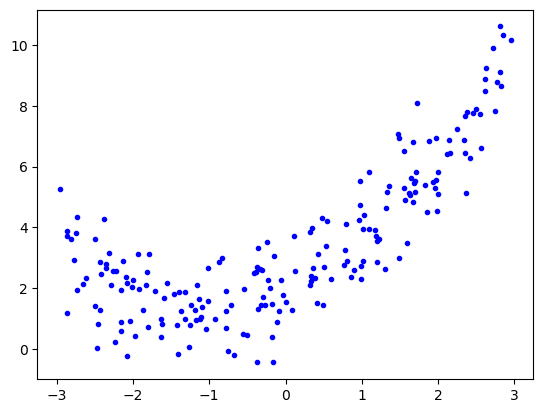

In [50]:
plt.plot(X, y, "b.",label="Nonlinear Data")
plt.show()

 - This is clearly a nonlinear data. Straight line will never  fit  this data properly. So let's use Scikit-Learn's PolynomialFeatures class to transform our training data, adding the square (second-degree polynomial) of each feature in the training set as a new feature.

In [52]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

array([1.64373629])

In [54]:
X_poly[0]

array([1.64373629, 2.701869  ])

In [57]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y) 
lin_reg.intercept_, lin_reg.coef_

(array([2.00540719]), array([[1.11022126, 0.50526985]]))

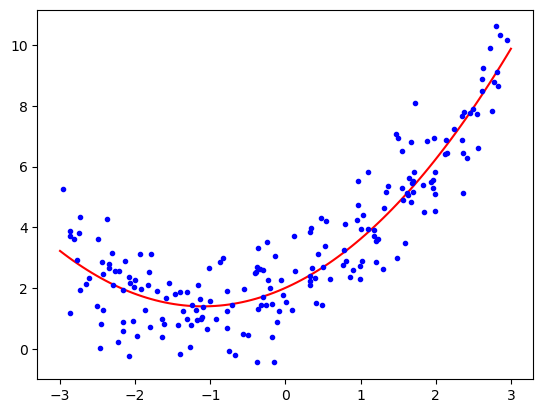

In [67]:
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.plot(X_new, y_new, "r-", label="Polynomial regression plot")
plt.plot(X, y, "b.")
plt.show()

### Learning Curves

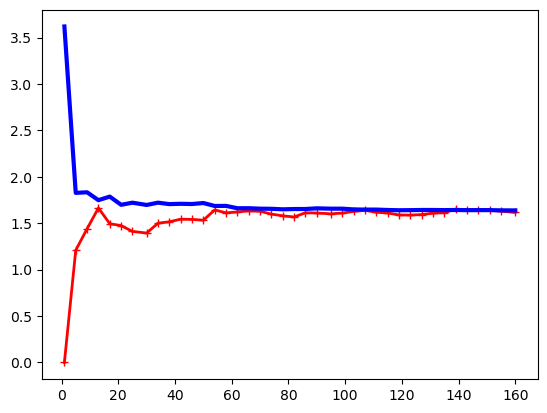

In [70]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores =  learning_curve(LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5,scoring="neg_root_mean_squared_error")
train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1) 

plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.show()

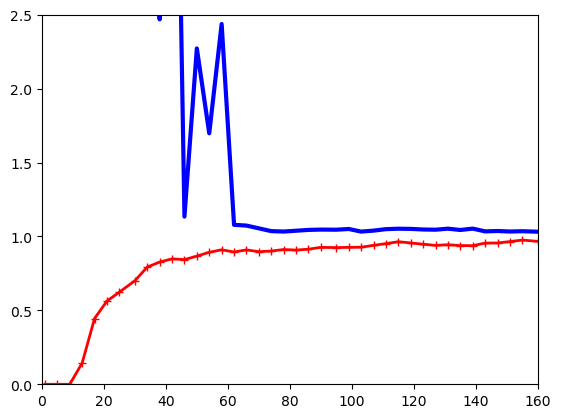

In [84]:
# Now let's look at the learning curves of a 10th-degree polynomial model on the same data 
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree=10, include_bias=False), 
    LinearRegression()
)

train_sizes, train_scores, valid_scores = learning_curve(
    polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5, scoring="neg_root_mean_squared_error"
)

train_errors = -train_scores.mean(axis=1)
valid_errors = -valid_scores.mean(axis=1)
plt.plot(train_sizes, train_errors, "r-+", linewidth=2, label="train")
plt.plot(train_sizes, valid_errors, "b-", linewidth=3, label="valid")
plt.axis([0,160, 0, 2.5])
plt.show()

### The Bias Variance Trade-Off

A model's generalization error can be  expressed as the sum of three very different errors : <br> 
 - `Bias` : This part of the generalization error is due to <b>wrong assumptions</b>, such as assuming that the data is linear when it is actually quadratic. A high-bias model is most likely to underfit the training data.
 - `Variance` : This part is due to the model's <b>excessive sensitivity to sall variations in the training data</b>. A model with many degrees of freedom (such as a high-degree polynomial model) is likely to have high variance and thus overfit the training data.
 - `Irreducible error` : This part is due to the <b>noisiness of the data</b> itself. The only way to reduce this part of the error is to clean up the data (e.g., fix the data sources, such as broken sensors, or detect and remove outliers).

Increasing a model's complexity will typically increase its variance and reduce its bias. Conversely, reducing a model's complexity (or increasing regularization) increases its bias and reduces its variance. This is why it is called a trade-off.

## Regularized Linear Models 

### Ridge Regression

In [93]:
# Here we add a regularization term equal to alpha/m * sum(theta<i>^2) for i in range(1, n) 

from sklearn.linear_model import Ridge 
ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X,y) 
ridge_reg.predict([[1.5]])

array([[5.06157854]])

In [95]:
# And using stochastic gradient descent : 
sgd_reg = SGDRegressor(penalty="l2", alpha=0.1/m, tol=None, max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X, y.ravel()) # y.ravel() because fit() expects 1D targets 
sgd_reg.predict([[1.5]])

array([5.06208065])

### Lasso Regression

In [98]:
# Here we add a different regularized term. In Ridge we added squared term, here we will add modulo term. 
# The term is equal to 2 * alpha * sum(modulo(Thetai)) for i in range(1, n) 

from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([5.00803756])

### Elastic Net Regression

In [101]:
# Here we combine both Ridge and Lasso Together and add a term that will combine both of them together.
# The term is equal to r * (Lasso regularized term) + (1 - r) * (Ridge Regularized term) where r is mix ratio.

from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X,y) 
elastic_net.predict([[1.5]])

array([5.006944])

### Early Stopping 

In [106]:
# A different way to regularize iterative learning algorithm such as gradient descent is to stop training as soon as the validation error reaches
# a minimum. 

from copy import deepcopy
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler

X_train, y_train = X[: m // 2], y[: m // 2, 0]
X_valid, y_valid = X[m // 2 :], y[m // 2 :, 0]

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False), StandardScaler())

X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid) 
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs=500
best_valid_rmse = float("inf")

for epoch in range(n_epochs): 
    sgd_reg.partial_fit(X_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = root_mean_squared_error(y_valid, y_valid_predict)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

In [110]:
best_model.intercept_

array([3.16509051])

# Logistic Regression 

Logistic regression is commonly used to estimate the probability that an instance belongs to a particular class (e.g., whwat is the probability that this email is spam?). This classifier is binary classifier. <br> 

`Estimating Probabilities` : <br> 
<b> p = sigma(ɵ<sup>T</sup> x ), where sigma(t) = 1 / (1 + exp(-t))<b> 

y_predicted = {0 if p < 0.5 else 1}

`Logistic Regression Cost function (log loss)` : <br>

<b>J(ɵ) = - (1 / m) * sum(y_i*log(p_i) + (1 - y_i)*log(1 - p_i)) for i in range(1, m)</b>

In [117]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [119]:
iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [121]:
iris.target.head(3)

0    0
1    0
2    0
Name: target, dtype: int32

In [123]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [125]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data[["petal width (cm)"]].values
y = iris.target_names[iris.target] == 'virginica'
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

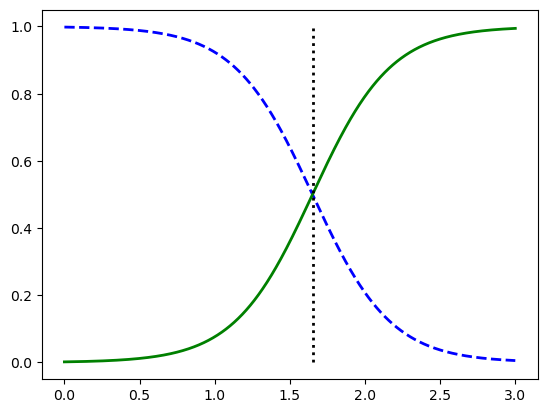

In [127]:
X_new = np.linspace(0,3, 1000).reshape(-1,1) # Reshape to get a column vector
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:, 1] >= 0.5][0, 0] 

plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2, label="Not Iris Virginica Proba")
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris Virginica Proba") 
plt.plot([decision_boundary, decision_boundary], [0,1], "k:", linewidth=2, label="decision Boundary")
plt.show()

In [129]:
decision_boundary

1.6516516516516517

In [131]:
log_reg.predict([[1.7],[1.5]])

array([ True, False])

### Softmax Regression

Logistic Regression can be generalized to support multiple classes directly, without having to train and combine multiple binary classifiers. This  is called softmax regression, or multinomial logistic regression. <br> 

`Softmax score for class k` : <br>
<b>s<sub>k</sub>(x) = (ɵ<sup>(k)</sup>)<sup>T</sup>x</b> <br><br>

`Softmax function` : <br>
<b> p<sub>k</sub> = sigma(s(x))<sub>k</sub> = exp(s<sub>k</sub>(x)) / sum(exp(s<sub>j</sub>(x)) for j in range(1, K)) </b> <br>

In this equation : 
 - K is the number of classes.
 - s(x) is a vector containing the scores of each class for the instance x.
 - sigma(s(x))<sub>k</sub> is the estimated probability that the instance x belongs to class k, given the scores of each class for that instance. 

In [136]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values 
y = iris["target"] 
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

softmax_reg = LogisticRegression(C=30, random_state=42) # Decrease C to increase regularization
softmax_reg.fit(X_train, y_train)

LogisticRegression(C=30, random_state=42)

In [138]:
softmax_reg.predict([[5, 2]])

array([2])

In [140]:
softmax_reg.predict_proba([[5, 2]]).round(2)

array([[0.  , 0.04, 0.96]])